# Step 2 — LEO Satellite Backhaul Simulation
Simulates Starlink LEO satellite link availability and latency under tropical weather conditions, using a physical link-budget model (ITU-R P.838 rain attenuation, official Starlink parameters) calibrated against López et al. (2023).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED         = 42
SIM_DURATION = 86400   # 24 hours, matching Step 1
TIME_STEP_S  = 10      # weather state update interval

# Starlink Gen1 orbital parameters
ALTITUDE_KM     = 550.0
INCLINATION_DEG = 53.0
FREQ_GHZ        = 12.0    # Ku-band downlink
EARTH_RADIUS_KM = 6371.0
GROUND_LAT_DEG  = -2.0    # South Kalimantan
ELEV_MIN_DEG    = 25.0

# Link budget : values from Starlink's Ofcom regulatory filing (Starlink Annex,
# Kepler Communications consultation) and FCC blanket licence for the UT2 terminal.
# EIRP = -52.3 dBW/Hz + 10*log10(240e6 Hz) = 31.5 dBW = 61.5 dBm,
# where 240 MHz per channel comes from Humphreys et al. signal structure measurements.
EIRP_DBM            = 61.5
RX_ANTENNA_GAIN_DBI = 33.2   # Starlink UT2, FCC blanket licence
MISC_LOSSES_DB      = 2.0    # pointing + polarisation + implementation margin
SENSITIVITY_DBM     = -89.0  # Starlink Gen2 Standard Actuated Dish spec

# ITU-R P.838 rain attenuation coefficients for circular polarisation at 12 GHz.
# Starlink uses circular polarisation (RHCP/LHCP), so k and alpha are the average
# of the H and V values from Table 1 of P.838 (the cos(2*tau) term drops out at tau=45 deg).
RAIN_K     = (0.0188 + 0.0168) / 2
RAIN_ALPHA = (0.0188 * 1.217 + 0.0168 * 1.200) / (2 * RAIN_K)

print(f"Altitude    : {ALTITUDE_KM} km")
print(f"Frequency   : {FREQ_GHZ} GHz (Ku-band)")
print(f"EIRP        : {EIRP_DBM} dBm")
print(f"Sensitivity : {SENSITIVITY_DBM} dBm")
print(f"Rain K      : {RAIN_K:.4f}  |  Rain alpha : {RAIN_ALPHA:.4f}")

Altitude    : 550.0 km
Frequency   : 12.0 GHz (Ku-band)
EIRP        : 61.5 dBm
Sensitivity : -89.0 dBm
Rain K      : 0.0178  |  Rain alpha : 1.2090


## Weather Markov Chain

Models time-varying tropical rain using a 4-state Markov chain. Rain rates within
each state are sampled uniformly, adding intra-state variability. The transition
matrix is calibrated to reflect brief, intense tropical storm events with fast recovery.

In [3]:
WEATHER_STATES = {
    'clear':    {'rain_rate_range': (0.0,  0.0),  'label': 'Clear'},
    'light':    {'rain_rate_range': (0.1,  9.9),  'label': 'Light Rain'},
    'moderate': {'rain_rate_range': (10.0, 29.9), 'label': 'Moderate Rain'},
    'heavy':    {'rain_rate_range': (30.0, 50.0), 'label': 'Heavy / Tropical Storm'},
}
STATE_NAMES = list(WEATHER_STATES.keys())

# Time step = 10s; probabilities reflect short dwell times in the heavy state.
TRANSITION_MATRIX = {
    'clear':    {'clear': 0.995, 'light': 0.005, 'moderate': 0.0,  'heavy': 0.0 },
    'light':    {'clear': 0.05,  'light': 0.90,  'moderate': 0.05, 'heavy': 0.0 },
    'moderate': {'clear': 0.01,  'light': 0.10,  'moderate': 0.80, 'heavy': 0.09},
    'heavy':    {'clear': 0.0,   'light': 0.05,  'moderate': 0.15, 'heavy': 0.80},
}


def simulate_weather_timeline(duration_s, time_step_s, rng, initial_state='clear'):
    n_steps = int(duration_s / time_step_s)
    timeline = []
    current_state = initial_state
    for step in range(n_steps):
        t = step * time_step_s
        low, high = WEATHER_STATES[current_state]['rain_rate_range']
        rain_rate = rng.uniform(low, high)
        timeline.append((t, current_state, rain_rate))
        probs = TRANSITION_MATRIX[current_state]
        current_state = rng.choice(STATE_NAMES, p=[probs[s] for s in STATE_NAMES])
    return timeline

print("Weather Markov chain ready.")

Weather Markov chain ready.


## Link Budget Model
P_rx (dBm) = EIRP - FSPL - A_rain - L_misc + G_rx

Elevation angles are sampled from a Beta distribution skewed toward high elevations,
reflecting Starlink's satellite-selection behaviour (>80% of selected satellites
at 45–90° per published statistics). Rain attenuation follows ITU-R P.838/P.618.
Effective path length uses the simplified form: L_eff = h_rain / sin(elevation).

In [ ]:
def max_central_angle_for_visibility(altitude_km, min_elev_deg=ELEV_MIN_DEG,
                                      earth_radius_km=EARTH_RADIUS_KM):
    min_elev_rad = np.radians(min_elev_deg)
    r_e = earth_radius_km
    r_s = earth_radius_km + altitude_km
    sin_gamma = (r_e / r_s) * np.cos(min_elev_rad)
    gamma = np.arcsin(sin_gamma)
    return np.degrees(np.pi / 2 - min_elev_rad - gamma)


def central_angle_to_elevation(central_angle_deg, altitude_km=ALTITUDE_KM,
                                earth_radius_km=EARTH_RADIUS_KM):
    gamma_rad = np.radians(central_angle_deg)
    r_e = earth_radius_km
    r_s = earth_radius_km + altitude_km
    return np.degrees(np.arctan2(np.cos(gamma_rad) - (r_e / r_s), np.sin(gamma_rad)))


def can_reach_zenith(ground_lat_deg=GROUND_LAT_DEG, inclination_deg=INCLINATION_DEG):
    return abs(ground_lat_deg) <= inclination_deg


def sample_elevation_angle(rng, ground_lat_deg=GROUND_LAT_DEG,
                            inclination_deg=INCLINATION_DEG, altitude_km=ALTITUDE_KM):
    max_angle = max_central_angle_for_visibility(altitude_km)
    central_angle = rng.beta(1.0, 2.2) * max_angle
    elevation = central_angle_to_elevation(central_angle, altitude_km)
    if not can_reach_zenith(ground_lat_deg, inclination_deg):
        lat_excess = abs(ground_lat_deg) - inclination_deg
        elevation = np.clip(elevation - lat_excess * 2, -90, 90)
    return elevation


def slant_range_km(elevation_deg, altitude_km=ALTITUDE_KM, earth_radius_km=EARTH_RADIUS_KM):
    elev_rad = np.radians(elevation_deg)
    r_e = earth_radius_km
    h = altitude_km
    return -r_e * np.sin(elev_rad) + np.sqrt((r_e * np.sin(elev_rad))**2 + h**2 + 2 * h * r_e)


def effective_path_length_km(elevation_deg, rain_height_km=4.86):
    # Simplified form of ITU-R P.618 : omits horizontal reduction factor and vertical adjustment, so this tends to slightly overestimate attenuation
    # rain_height_km=4.86 is the ITU-R recommended default for tropical regions
    elev_rad = np.radians(max(elevation_deg, 5.0))
    return rain_height_km / np.sin(elev_rad)


def free_space_path_loss_db(distance_km, freq_ghz=FREQ_GHZ):
    freq_mhz = freq_ghz * 1000
    return 20 * np.log10(distance_km) + 20 * np.log10(freq_mhz) + 32.44


def rain_attenuation_db(rain_rate_mmhr, elevation_deg, rng):
    if rain_rate_mmhr <= 0:
        return 0.0
    l_eff = effective_path_length_km(elevation_deg)
    a_rain = RAIN_K * (rain_rate_mmhr ** RAIN_ALPHA) * l_eff
    return max(0.0, a_rain * rng.normal(1.0, 0.15))


def calculate_satellite_rssi(rain_rate_mmhr, elevation_deg, rng):
    distance_km = slant_range_km(elevation_deg)
    fspl = free_space_path_loss_db(distance_km)
    rain_atten = rain_attenuation_db(rain_rate_mmhr, elevation_deg, rng)
    rx_power_dbm = EIRP_DBM - fspl - rain_atten - MISC_LOSSES_DB + RX_ANTENNA_GAIN_DBI
    return rx_power_dbm, rain_atten, distance_km


def calculate_latency_ms(distance_km, rain_atten_db, rng):
    # Propagation + processing overhead calibrated to match López et al. (2023)
    # clear-sky statistics (mean 64.2 ms, std 30.6 ms)
    propagation_ms = (distance_km / 299792.458) * 1000 * 2
    processing_overhead_ms = max(5.0, rng.normal(59.25, 31.75))
    rain_penalty_ms = rng.exponential(rain_atten_db * 15) if rain_atten_db > 3 else 0.0
    return max(5.0, propagation_ms + processing_overhead_ms + rain_penalty_ms)

print("Link budget model ready.")
print(f"Ground station within {INCLINATION_DEG} deg inclination band: {can_reach_zenith()}")

Link budget model ready.
Ground station within 53.0 deg inclination band: True


## Calibration Check — López et al. (2023)

Verifies that the model reproduces clear-sky statistics from López et al. (2023):
availability 100%, mean latency 64.2 ms, std 30.6 ms.

In [5]:
def calibration_check(n_samples=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    latencies = []
    successes = 0
    for _ in range(n_samples):
        elevation = sample_elevation_angle(rng)
        rssi, rain_atten, distance_km = calculate_satellite_rssi(0.0, elevation, rng)
        if rssi >= SENSITIVITY_DBM:
            successes += 1
            latencies.append(calculate_latency_ms(distance_km, rain_atten, rng))
    print(f"{'Metric':<25} {'Simulated':>12} {'Lopez et al.':>14}")
    print(f"{'Availability':<25} {successes/n_samples:>11.1%} {'100%':>14}")
    print(f"{'Mean latency (ms)':<25} {np.mean(latencies):>12.1f} {'64.2':>14}")
    print(f"{'Std latency (ms)':<25} {np.std(latencies):>12.1f} {'30.6':>14}")

calibration_check()

Metric                       Simulated   Lopez et al.
Availability                   100.0%           100%
Mean latency (ms)                 64.0           64.2
Std latency (ms)                  30.7           30.6


## Full 24-Hour Simulation

Runs a backhaul packet attempt every 30 seconds over a Markov-chain weather timeline,
computing received power, link availability, and latency for each attempt.

In [6]:
def run_satellite_simulation(duration=SIM_DURATION, time_step=TIME_STEP_S,
                              seed=SEED, packet_interval_s=30,
                              sensitivity_dbm=SENSITIVITY_DBM):
    rng = np.random.default_rng(seed)
    weather_timeline = simulate_weather_timeline(duration, time_step, rng)
    weather_df = pd.DataFrame(weather_timeline, columns=['time', 'state', 'rain_rate_mmhr'])
    weather_lookup = weather_df.set_index('time')

    log = []
    t = 0.0
    while t < duration:
        idx = int(t // time_step) * time_step
        row = (weather_lookup.loc[weather_lookup.index <= idx].iloc[-1]
               if idx in weather_lookup.index else weather_lookup.iloc[0])
        state, rain_rate = row['state'], row['rain_rate_mmhr']

        elevation = sample_elevation_angle(rng)
        rssi, rain_atten, distance_km = calculate_satellite_rssi(rain_rate, elevation, rng)
        success = rssi >= sensitivity_dbm
        latency_ms = calculate_latency_ms(distance_km, rain_atten, rng) if success else np.nan

        log.append({'time': t, 'weather_state': state, 'rain_rate_mmhr': rain_rate,
                    'elevation_deg': elevation, 'distance_km': distance_km,
                    'rain_atten_db': rain_atten, 'rssi_dbm': rssi,
                    'success': success, 'latency_ms': latency_ms})
        t += packet_interval_s

    df = pd.DataFrame(log)
    total = len(df)
    overall_availability = df['success'].sum() / total if total > 0 else 0

    per_state = df.groupby('weather_state').agg(
        total_attempts=('success', 'count'), successes=('success', 'sum'))
    per_state['availability']    = per_state['successes'] / per_state['total_attempts']
    per_state['mean_latency_ms'] = df[df['success']].groupby('weather_state')['latency_ms'].mean()
    per_state['std_latency_ms']  = df[df['success']].groupby('weather_state')['latency_ms'].std()

    results = {
        'total_attempts':       total,
        'overall_availability': overall_availability,
        'mean_latency_ms':      df.loc[df['success'], 'latency_ms'].mean(),
        'std_latency_ms':       df.loc[df['success'], 'latency_ms'].std(),
        'per_state':            per_state,
    }
    return results, df, weather_df


results, df_sat, weather_df = run_satellite_simulation()

print(f"Overall availability : {results['overall_availability']:.2%}")
print(f"Overall mean latency : {results['mean_latency_ms']:.1f} ms")
print(f"Overall std latency  : {results['std_latency_ms']:.1f} ms")
print()
print("Per-state breakdown:")
print(results['per_state'][['total_attempts', 'successes', 'availability', 'mean_latency_ms']].round(3))

Overall availability : 99.83%
Overall mean latency : 67.3 ms
Overall std latency  : 37.4 ms

Per-state breakdown:
               total_attempts  successes  availability  mean_latency_ms
weather_state                                                          
clear                    2538       2538         1.000           65.363
heavy                      19         14         0.737          200.676
light                     244        244         1.000           63.431
moderate                   79         79         1.000          118.089


## Results Visualisation

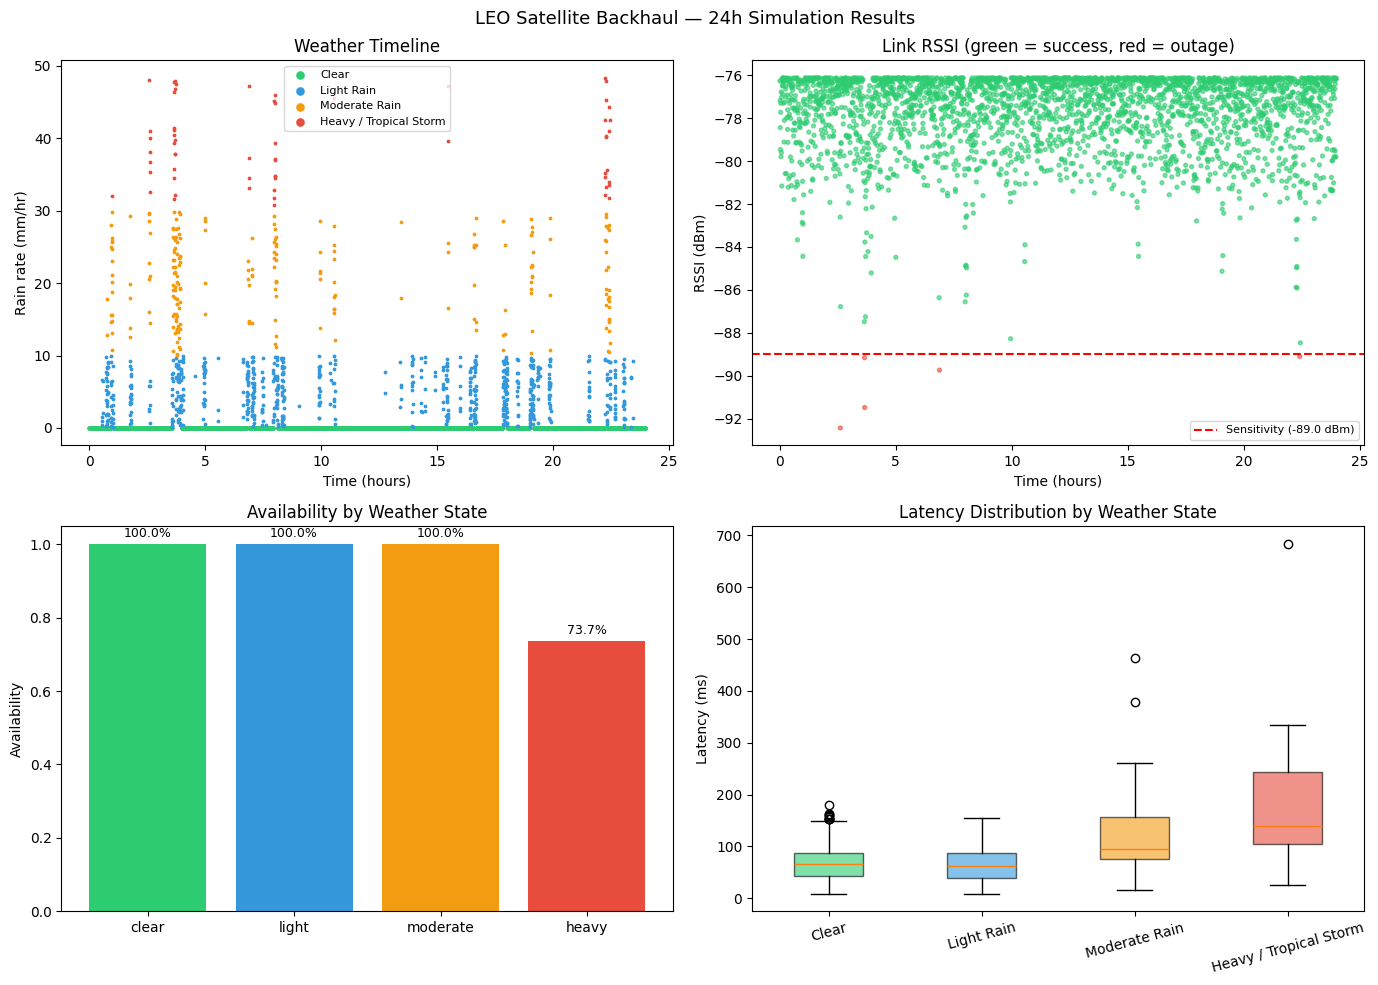

In [7]:
def plot_results(df, weather_df, results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("LEO Satellite Backhaul — 24h Simulation Results", fontsize=13)

    state_colors = {
        'clear': '#2ecc71', 'light': '#3498db',
        'moderate': '#f39c12', 'heavy': '#e74c3c'
    }

    ax = axes[0, 0]
    for state, color in state_colors.items():
        mask = weather_df['state'] == state
        ax.scatter(weather_df.loc[mask, 'time'] / 3600,
                   weather_df.loc[mask, 'rain_rate_mmhr'],
                   c=color, s=3, label=WEATHER_STATES[state]['label'])
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Rain rate (mm/hr)')
    ax.set_title('Weather Timeline')
    ax.legend(fontsize=8, markerscale=3)

    ax = axes[0, 1]
    colors = df['success'].map({True: '#2ecc71', False: '#e74c3c'})
    ax.scatter(df['time'] / 3600, df['rssi_dbm'], c=colors, s=8, alpha=0.6)
    ax.axhline(SENSITIVITY_DBM, color='red', linestyle='--',
               label=f'Sensitivity ({SENSITIVITY_DBM} dBm)')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('RSSI (dBm)')
    ax.set_title('Link RSSI (green = success, red = outage)')
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    state_order = ['clear', 'light', 'moderate', 'heavy']
    per_state = results['per_state'].reindex(
        [s for s in state_order if s in results['per_state'].index])
    bars = ax.bar(per_state.index, per_state['availability'],
                   color=[state_colors[s] for s in per_state.index])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Availability')
    ax.set_title('Availability by Weather State')
    for bar, val in zip(bars, per_state['availability']):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f'{val:.1%}', ha='center', fontsize=9)

    ax = axes[1, 1]
    plot_data = [
        df.loc[(df['weather_state'] == s) & df['success'], 'latency_ms'].dropna()
        for s in state_order if s in df['weather_state'].unique()
    ]
    plot_labels = [
        WEATHER_STATES[s]['label']
        for s in state_order if s in df['weather_state'].unique()
    ]
    bp = ax.boxplot(plot_data, tick_labels=plot_labels, patch_artist=True)
    for patch, s in zip(bp['boxes'], state_order):
        patch.set_facecolor(state_colors[s])
        patch.set_alpha(0.6)
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution by Weather State')
    ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('leo_satellite_results.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_results(df_sat, weather_df, results)

## Save Outputs

In [8]:
df_sat.to_csv('satellite_sim_log.csv', index=False)
weather_df.to_csv('weather_timeline.csv', index=False)
print("Saved satellite_sim_log.csv and weather_timeline.csv")

Saved satellite_sim_log.csv and weather_timeline.csv


## Export Per-Window Data for Step 3

Aggregates the simulation log into 30-minute windows and saves to CSV.
This file is read directly by the Step 3 decision system for inference.

In [9]:
WINDOW_S_SAT   = 1800
WEATHER_ENCODE = {'clear': 0, 'light': 1, 'moderate': 2, 'heavy': 3}

df_sat['window'] = (df_sat['time'] // WINDOW_S_SAT).astype(int)

sat_windows = df_sat.groupby('window').agg(
    sat_availability=('success',        'mean'),
    sat_latency_ms  =('latency_ms',     'mean'),
    sat_rssi_dbm    =('rssi_dbm',       'mean'),
    rain_rate_mmhr  =('rain_rate_mmhr', 'mean'),
).reset_index()

weather_mode = df_sat.groupby('window')['weather_state'].agg(lambda x: x.mode()[0])
sat_windows['weather_encoded'] = weather_mode.map(WEATHER_ENCODE).values
sat_windows['sat_latency_ms']  = sat_windows['sat_latency_ms'].fillna(9999)

sat_windows.to_csv('satellite_windows.csv', index=False)
print(f"Saved satellite_windows.csv — {len(sat_windows)} windows of {WINDOW_S_SAT // 60} minutes")
print(sat_windows[['window', 'sat_availability', 'sat_latency_ms', 'weather_encoded']].head(5))

Saved satellite_windows.csv — 48 windows of 30 minutes
   window  sat_availability  sat_latency_ms  weather_encoded
0       0               1.0       74.731930                0
1       1               1.0       75.273399                0
2       2               1.0       72.779505                0
3       3               1.0       58.329250                0
4       4               1.0       72.123824                0


## Multi-Seed Analysis (100 Runs)

Runs the simulation 100 times with different seeds to quantify availability and latency
variability across weather states. Mean ± std gives a more robust estimate than a single seed.

In [12]:
SEEDS       = list(range(100))
STATE_ORDER = ['clear', 'light', 'moderate', 'heavy']

all_availability = {s: [] for s in STATE_ORDER}
all_latency_mean = {s: [] for s in STATE_ORDER}
all_overall_avail   = []
all_overall_latency = []

print(f"Running {len(SEEDS)} simulations...\n")
print(f"{'Seed':<6} {'Clear Avail':>12} {'Mod Avail':>11} {'Heavy Avail':>12} "
      f"{'Clear Lat':>11} {'Mod Lat':>10} {'Heavy Lat':>11}")
print("-" * 76)

for seed in SEEDS:
    res, _, _ = run_satellite_simulation(seed=seed)
    ps = res['per_state']

    all_overall_avail.append(res['overall_availability'])
    all_overall_latency.append(res['mean_latency_ms'])

    for state in STATE_ORDER:
        if state in ps.index:
            all_availability[state].append(ps.loc[state, 'availability'])
            all_latency_mean[state].append(ps.loc[state, 'mean_latency_ms'])
        else:
            all_availability[state].append(float('nan'))
            all_latency_mean[state].append(float('nan'))

    if seed % 10 == 0:
        print(f"{seed:<6} "
              f"{all_availability['clear'][-1]:>11.1%} "
              f"{all_availability['moderate'][-1]:>10.1%} "
              f"{all_availability['heavy'][-1]:>11.1%} "
              f"{all_latency_mean['clear'][-1]:>10.1f} ms "
              f"{all_latency_mean['moderate'][-1]:>8.1f} ms "
              f"{all_latency_mean['heavy'][-1]:>9.1f} ms")

print("\n" + "=" * 70)
print(f"Overall availability : {np.mean(all_overall_avail):.2%} ± {np.std(all_overall_avail):.2%}")
print(f"Overall mean latency : {np.mean(all_overall_latency):.1f} ms ± {np.std(all_overall_latency):.1f} ms")
print()
print(f"{'State':<12} {'Avail Mean':>12} {'Avail Std':>11} {'Lat Mean':>10} {'Lat Std':>10}")
print("-" * 57)
for state in STATE_ORDER:
    a_vals = [v for v in all_availability[state] if not np.isnan(v)]
    l_vals = [v for v in all_latency_mean[state] if not np.isnan(v)]
    print(f"{state:<12} {np.mean(a_vals):>11.1%} {np.std(a_vals):>10.1%} "
          f"{np.mean(l_vals):>9.1f} ms {np.std(l_vals):>8.1f} ms")

Running 100 simulations...

Seed    Clear Avail   Mod Avail  Heavy Avail   Clear Lat    Mod Lat   Heavy Lat
----------------------------------------------------------------------------
0           100.0%     100.0%       76.3%       64.4 ms    112.3 ms     171.8 ms
10          100.0%     100.0%       82.8%       63.8 ms    110.7 ms     166.9 ms
20          100.0%      98.6%       83.3%       64.3 ms    106.0 ms     203.2 ms
30          100.0%      97.2%       85.4%       65.1 ms    113.6 ms     201.4 ms
40          100.0%      95.7%       69.7%       65.8 ms    105.2 ms     217.2 ms
50          100.0%      97.5%       75.7%       64.8 ms    101.2 ms     152.9 ms
60          100.0%      98.0%       82.1%       63.3 ms    131.5 ms     167.7 ms
70          100.0%     100.0%       84.6%       63.0 ms    120.7 ms     176.0 ms
80          100.0%      98.5%       85.3%       64.0 ms    109.3 ms     166.4 ms
90          100.0%      97.8%       70.7%       64.0 ms    121.0 ms     179.7 ms

Over

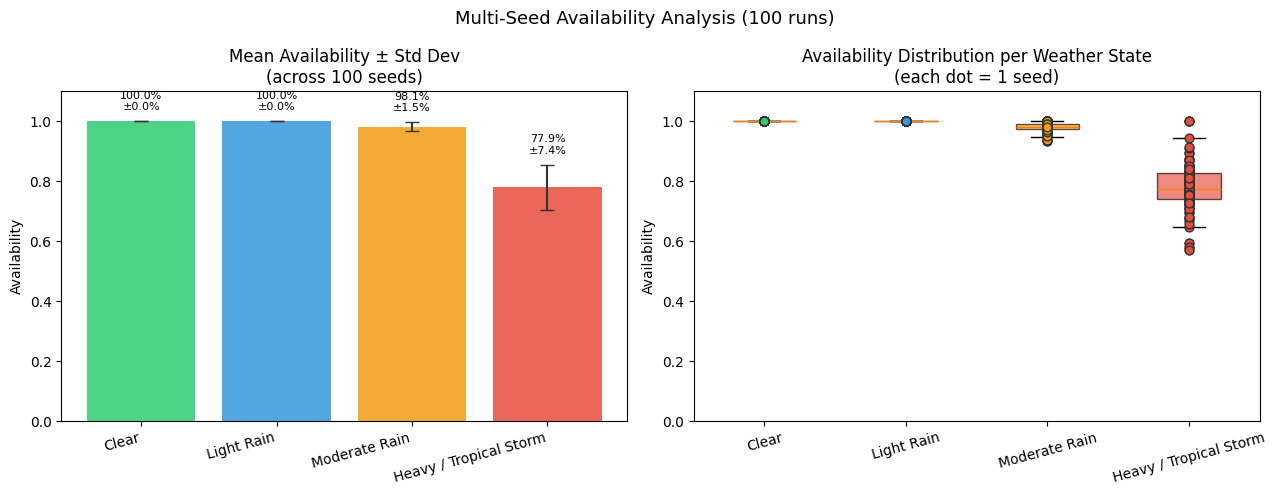

Saved leo_satellite_multiseed_results.png


In [13]:
state_colors = {
    'clear': '#2ecc71', 'light': '#3498db',
    'moderate': '#f39c12', 'heavy': '#e74c3c'
}
state_labels = {s: WEATHER_STATES[s]['label'] for s in STATE_ORDER}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Multi-Seed Availability Analysis ({len(SEEDS)} runs)", fontsize=13)

# Bar chart: mean availability with error bars
ax = axes[0]
x_pos  = range(len(STATE_ORDER))
means  = [np.nanmean(all_availability[s]) for s in STATE_ORDER]
stds   = [np.nanstd(all_availability[s])  for s in STATE_ORDER]
colors = [state_colors[s] for s in STATE_ORDER]
labels = [state_labels[s] for s in STATE_ORDER]
bars = ax.bar(x_pos, means, color=colors, alpha=0.85, yerr=stds, capsize=5,
              error_kw={'ecolor': '#333', 'elinewidth': 1.5})
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.10)
ax.set_ylabel('Availability')
ax.set_title(f'Mean Availability ± Std Dev\n(across {len(SEEDS)} seeds)')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.03,
            f'{mean:.1%}\n±{std:.1%}', ha='center', va='bottom', fontsize=8)

# Box plot: availability distribution per state
ax = axes[1]
plot_data = [all_availability[s] for s in STATE_ORDER]
bp = ax.boxplot(plot_data, tick_labels=labels, patch_artist=True)
for patch, s in zip(bp['boxes'], STATE_ORDER):
    patch.set_facecolor(state_colors[s])
    patch.set_alpha(0.65)
ax.set_ylabel('Availability')
ax.set_title(f'Availability Distribution per Weather State\n(each dot = 1 seed)')
ax.set_ylim(0, 1.10)
ax.tick_params(axis='x', rotation=15)
for j, s in enumerate(STATE_ORDER):
    ax.scatter([j + 1] * len(all_availability[s]), all_availability[s],
               color=state_colors[s], edgecolors='#333', zorder=3, s=40)

plt.tight_layout()
plt.savefig('leo_satellite_multiseed_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved leo_satellite_multiseed_results.png")

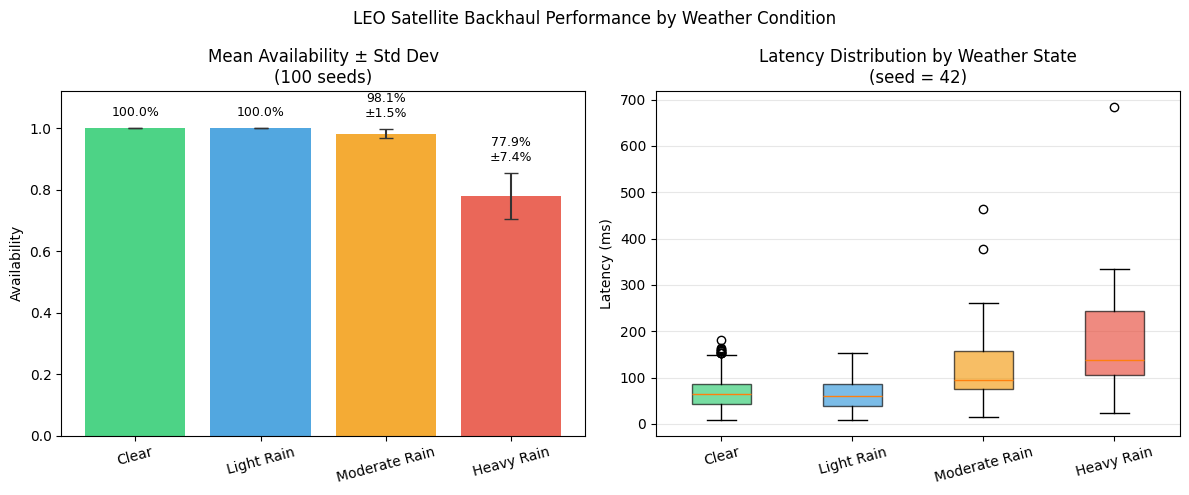

Saved leo_satellite_paper_figure.png


In [14]:
avail_means = [np.nanmean(all_availability[s]) for s in STATE_ORDER]
avail_stds  = [np.nanstd(all_availability[s])  for s in STATE_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LEO Satellite Backhaul Performance by Weather Condition", fontsize=12)

STATE_LABELS = ['Clear', 'Light Rain', 'Moderate Rain', 'Heavy Rain']
COLORS       = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

# Availability chart
ax = axes[0]
bars = ax.bar(STATE_LABELS, avail_means, color=COLORS, alpha=0.85,
              yerr=avail_stds, capsize=5,
              error_kw={'ecolor': '#333', 'elinewidth': 1.5})
ax.set_ylim(0, 1.12)
ax.set_ylabel('Availability')
ax.set_title('Mean Availability ± Std Dev\n(100 seeds)')
ax.tick_params(axis='x', rotation=15)
for bar, mean, std in zip(bars, avail_means, avail_stds):
    label = f'{mean:.1%}' if std < 0.001 else f'{mean:.1%}\n±{std:.1%}'
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.03,
            label, ha='center', va='bottom', fontsize=9)

# Latency box plot
ax = axes[1]
plot_data = [
    df_sat.loc[(df_sat['weather_state'] == s) & df_sat['success'], 'latency_ms'].dropna()
    for s in STATE_ORDER
]
bp = ax.boxplot(plot_data, tick_labels=STATE_LABELS, patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax.set_ylabel('Latency (ms)')
ax.set_title('Latency Distribution by Weather State\n(seed = 42)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('leo_satellite_paper_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved leo_satellite_paper_figure.png")

In [ ]:
summary_rows = []
for seed, row_avail in zip(SEEDS, zip(*[all_availability[s] for s in STATE_ORDER])):
    summary_rows.append({'seed': seed, **{s: v for s, v in zip(STATE_ORDER, row_avail)}})
summary_rows.append({'seed': 'mean', **{s: np.nanmean(all_availability[s]) for s in STATE_ORDER}})
summary_rows.append({'seed': 'std',  **{s: np.nanstd(all_availability[s])  for s in STATE_ORDER}})
pd.DataFrame(summary_rows).to_csv('multiseed_availability_summary.csv', index=False)
print("Saved multiseed_availability_summary.csv")

Saved multiseed_availability_summary.csv


: 